# Peak-productivity windows
Explains how each peak-productivity window was dated and at what age individuals flourished.

In [1]:
import tempfile
import numpy as np
import polars as pl
import duckdb
import matplotlib.pyplot as plt
from style import *

SEED = 42
np.random.seed(SEED)

DB_PATH = '../data/cultura/humans_clean_v2.duckdb'
BIN_WIDTH = 50
LAST_BIN = 2000
AGE_MIN, AGE_MAX = 10, 100

pl.Config.set_tbl_rows(40)
pl.Config.set_tbl_cols(12)
pl.Config.set_fmt_str_lengths(60)
pl.Config.set_tbl_width_chars(220)

apply_style()

## Load data — `occupation_stats`
Age at floruit per CV occupation and 50-year birth cohort, computed by `scripts/database_enrichment/05b_occupation_stats.py`. Filled points are measured on the cohort alone; hollow points borrow a wider pool. Each panel starts at the first cohort measured on its own.

In [2]:
con = duckdb.connect(DB_PATH, read_only=True)
floruit_stats = con.sql("""
    SELECT cv_occupation,
           date_range.start_year                                            AS birth_bin,
           productivity_window_from_wikidata_floruit.low                    AS low,
           productivity_window_from_wikidata_floruit.median                 AS median,
           productivity_window_from_wikidata_floruit.high                   AS high,
           floruit_n,
           field_provenance['productivity_window_from_wikidata_floruit'].rule
               LIKE '%Measured on the cohort alone.'                         AS observed
    FROM occupation_stats
    WHERE date_range.start_year <= $last_bin
""", params={'last_bin': LAST_BIN}).pl()
con.close()

print('shape:', floruit_stats.shape)
floruit_stats.group_by('cv_occupation').agg(pl.col('observed').sum().alias('observed_cohorts')).sort('cv_occupation')


shape: (777, 7)


cv_occupation,observed_cohorts
str,u32
"""All""",21
"""Culture""",12
"""Discovery/Science""",10
"""Leadership""",9
"""Missing""",0
"""Other""",5
"""Sports/Games""",3


## Figures

In [3]:
def cohorts(occupation):
    rows = floruit_stats.filter(pl.col('cv_occupation') == occupation).sort('birth_bin')
    first = rows.filter(pl.col('observed'))['birth_bin'].min()
    return rows.head(0) if first is None else rows.filter(pl.col('birth_bin') >= first)


def plot_window(ax, rows, band_color, line_color, label=True):
    x = rows['birth_bin'].to_numpy() + BIN_WIDTH / 2
    median = rows['median'].to_numpy()
    observed = rows['observed'].to_numpy()
    ax.fill_between(x, rows['low'], rows['high'], color=band_color, alpha=BAND_ALPHA, label='IQR (Q1–Q3)' if label else None)
    ax.plot(x, median, color=line_color, label='Median age at floruit' if label else None)
    ax.scatter(x[observed], median[observed], s=30, color=line_color, zorder=3)
    ax.scatter(x[~observed], median[~observed], s=30, facecolor=BACKGROUND_COLOR, edgecolor=line_color, lw=1.2, zorder=3)
    return x, median


### Figure 3A — Median age at floruit per birth cohort

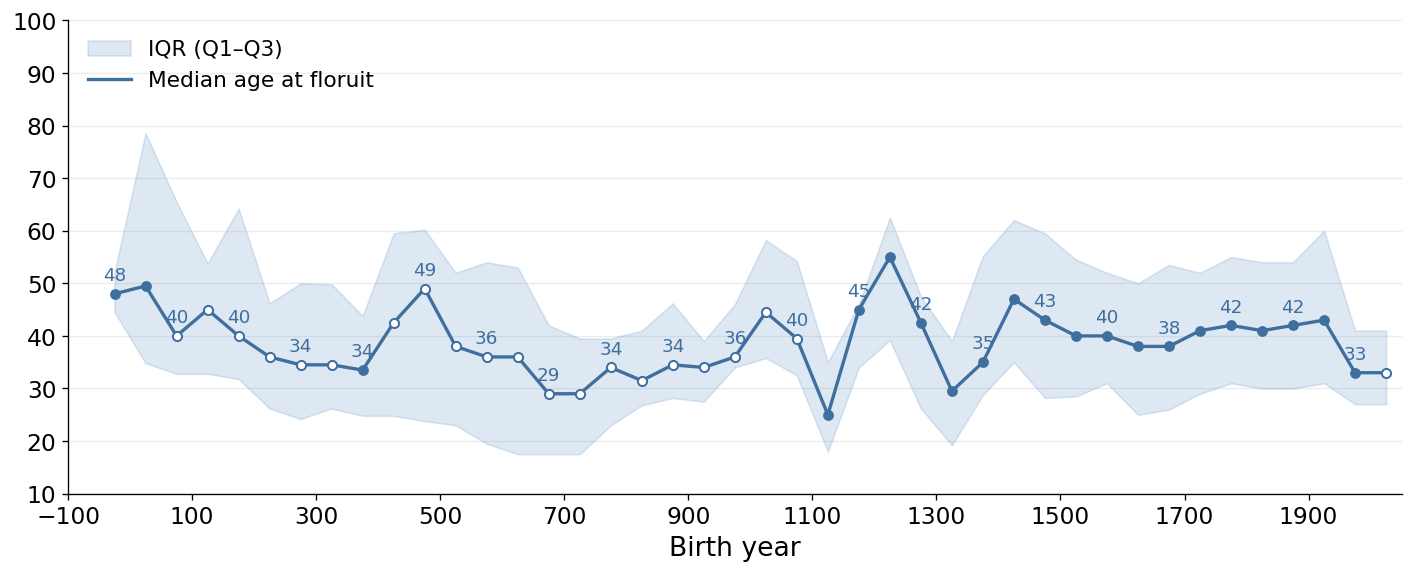

In [4]:
rows = cohorts('All')

fig, ax = plt.subplots()
xs, median = plot_window(ax, rows, MAIN_COLOR, MAIN_LINE_COLOR)
for i, (x, m) in enumerate(zip(xs, median)):
    if i % 2 == 0:
        ax.annotate(f'{m:.0f}', (x, m), xytext=(0, 8), textcoords='offset points',
                    ha='center', fontsize=POINT_LABEL_FONTSIZE, color=MAIN_LINE_COLOR)
first = int(rows['birth_bin'].min() // 100 * 100)
ax.set_xticks(range(first, LAST_BIN + BIN_WIDTH + 1, 200))
ax.set_xlim(first, LAST_BIN + BIN_WIDTH)
ax.set_ylim(AGE_MIN, AGE_MAX)
ax.set_xlabel('Birth year')
ax.grid(axis='y')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()


### Figure 3B — Median age at floruit per birth cohort, by occupational category

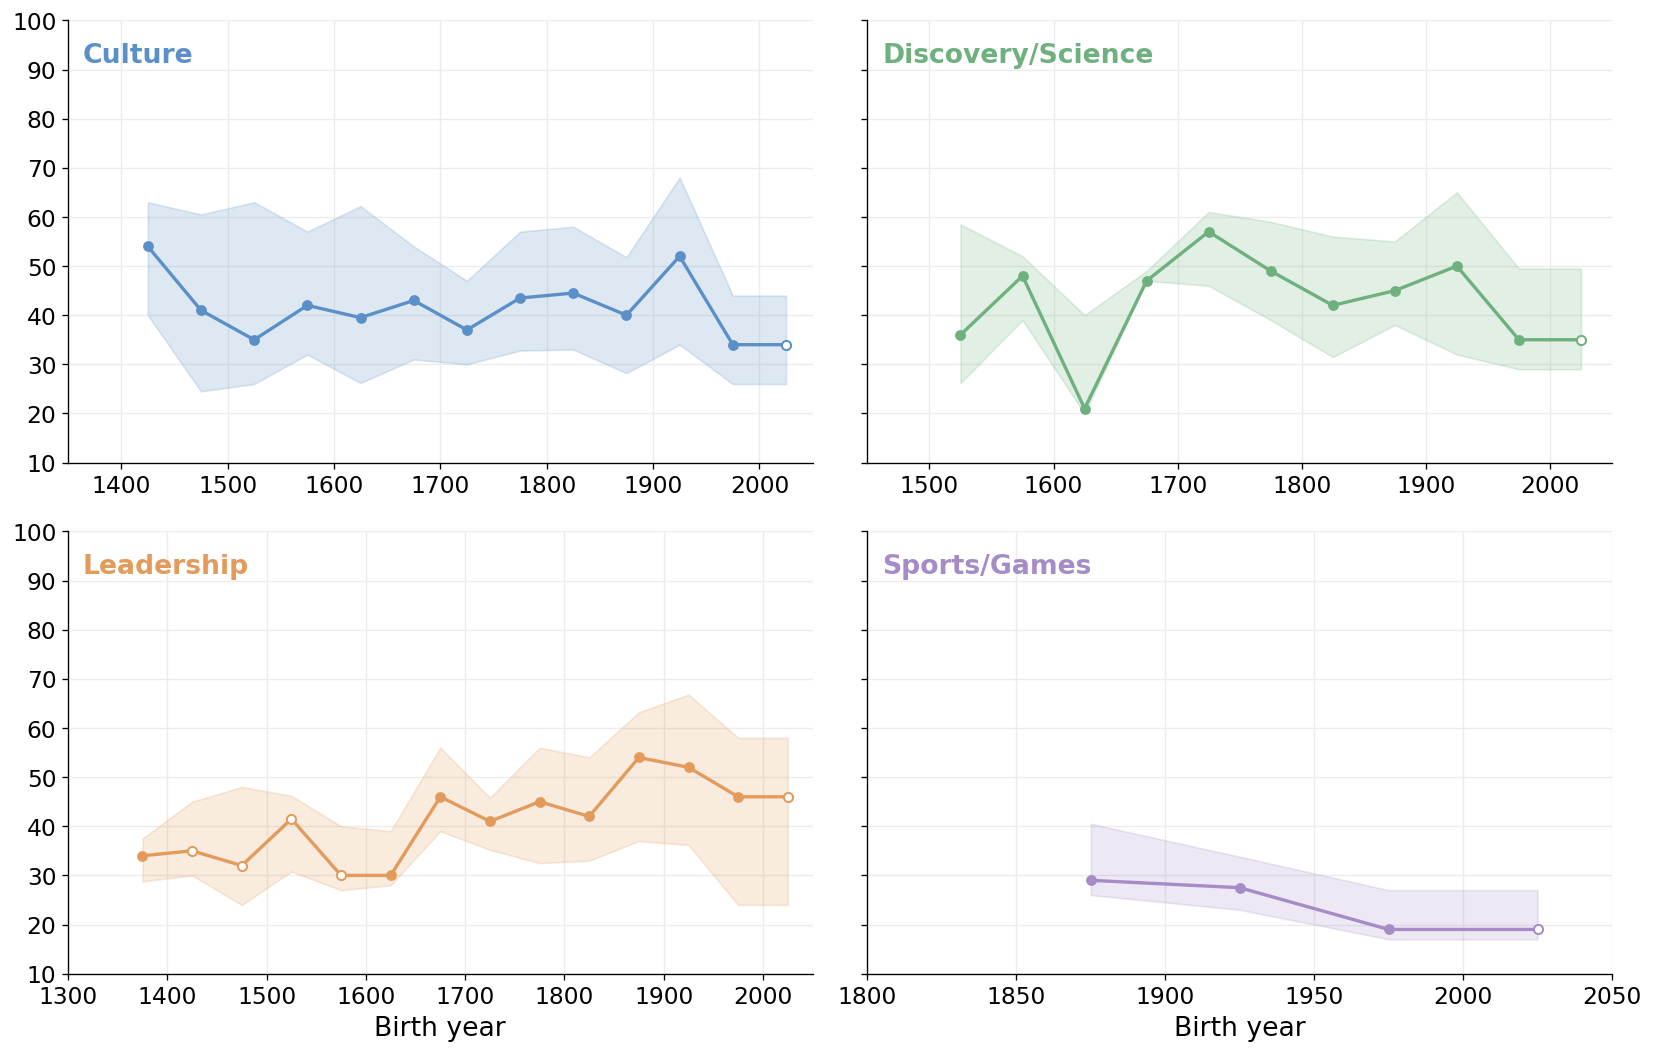

In [5]:
fig, axes = plt.subplots(2, 2, figsize=FIGSIZE_GRID, sharey=True)
for ax, (occupation, color) in zip(axes.flat, OCCUPATION_COLORS.items()):
    rows = cohorts(occupation)
    ax.text(0.02, 0.95, occupation, transform=ax.transAxes, fontsize=PANEL_LABEL_FONTSIZE, color=color, va='top', fontweight='bold')
    ax.set_ylim(AGE_MIN, AGE_MAX)
    ax.grid(True)
    if rows.is_empty():
        continue
    plot_window(ax, rows, color, color, label=False)
    ax.set_xlim(rows['birth_bin'].min() - BIN_WIDTH, LAST_BIN + BIN_WIDTH)
for ax in axes[-1, :]:
    ax.set_xlabel('Birth year')
plt.tight_layout()
plt.show()
